In [2]:
import os 
import zarr
import numpy as np
import matplotlib.pyplot as plt
import argparse


from matplotlib.colors import ListedColormap

In [3]:
root = zarr.open(r"C:\Users\saini\cellmap-segmentation-challenge\data\jrc_cos7-1a\jrc_cos7-1a.zarr", mode='r')

In [4]:
# training crops
train_crops = [
    {
        "crop": 292,
        "translation": [863.0, 5283.0, 6703.0]
    },
    {
        "crop": 254,
        "translation": [2827.0, 5053.0, 9351.0]
    },
    {
        "crop": 236,
        "translation": [ 11.0 , 5691.0, 11751.0]  
    },
    {
        "crop": 237,
        "translation": [2857.0, 4943.0, 10289.0]
    },
    {   
        "crop": 248,
        "translation":[91.0, 4301.0, 7923.0]
    },
    
]

scale = 4.0  


In [5]:
CLASS_LIST = [ "mito_mem", "mito_lum" , "cyto", "er_mem" ,"er_lum", "endo_mem", "endo_lum"]

TRAIN_CLASSES = ["background"] + CLASS_LIST

class_to_id = {cls: i for i, cls in enumerate(TRAIN_CLASSES)}
id_to_class = {i: cls for cls, i in class_to_id.items()}

NUM_CLASSES = len(TRAIN_CLASSES)

N_SAMPLES_PER_CLASS = 15000  # Total per class
BOUNDARY_RATIO = 0.4          # 40% boundary, 60% interior



In [54]:
import numpy as np
from scipy.ndimage import (
    gaussian_filter,
    gaussian_gradient_magnitude,
    laplace,
    sobel
)

def extract_features(volume, sigmas=(0.5, 1, 2, 4), add_coords=True):
    """
    volume: 3D numpy array (Z, Y, X)
    returns: (Z, Y, X, C) feature volume
    """

    Z, Y, X = volume.shape
    volume = volume.astype(np.float32)
    features = []

    # ---- RAW INTENSITY ----
    features.append(volume)

    for sigma in sigmas:
        # ---- SMOOTHING ----
        smoothed = gaussian_filter(volume, sigma=sigma)
        features.append(smoothed)

        # ---- EDGE FEATURES ----
        grad_mag = gaussian_gradient_magnitude(smoothed, sigma=1)
        features.append(grad_mag)

        lap = laplace(smoothed)
        features.append(lap)

        # ---- ORIENTATION (STRUCTURE) ----
        sx = sobel(smoothed, axis=2)
        sy = sobel(smoothed, axis=1)
        sz = sobel(smoothed, axis=0)
        features.extend([sx, sy, sz])

        # ---- TEXTURE FEATURES ----
        local_mean = gaussian_filter(volume, sigma=sigma)
        local_sq_mean = gaussian_filter(volume**2, sigma=sigma)
        local_var = local_sq_mean - local_mean**2
        local_std = np.sqrt(np.maximum(local_var, 1e-6))

        features.append(local_std)

        # ---- DIFFERENCE OF GAUSSIANS ----
        dog = gaussian_filter(volume, sigma=sigma) - gaussian_filter(volume, sigma=sigma * 1.6)
        features.append(dog)

    # ---- SPATIAL COORDINATES ----
    if add_coords:
        zz, yy, xx = np.meshgrid(
            np.linspace(0, 1, Z, dtype=np.float32),
            np.linspace(0, 1, Y, dtype=np.float32),
            np.linspace(0, 1, X, dtype=np.float32),
            indexing="ij"
        )
        features.extend([zz, yy, xx])

    feature_volume = np.stack(features, axis=-1)
    return feature_volume


In [55]:
import numpy as np
from scipy.ndimage import binary_erosion

def smart_sample_voxels(mask, n_samples=15000, boundary_ratio=0.4):
    """
    mask: (Z,Y,X) binary mask for one class
    n_samples: total samples to return
    boundary_ratio: fraction of samples to take from boundaries (0.4 = 40%)
    """

    
    coords = []

    
    # 1. Find all voxels of this class
    
    zyx = np.where(mask == 1)
    all_voxels = list(zip(zyx[0], zyx[1], zyx[2]))

    if len(all_voxels) == 0:
        return coords  # empty class in this crop

 
    # 2. Find boundary voxels (thin classes NEED this)
    
    eroded = binary_erosion(mask, iterations=1, border_value=0)
    boundary_mask = mask & (~eroded)

    bz, by, bx = np.where(boundary_mask == 1)
    boundary_voxels = list(zip(bz, by, bx))


    # How many samples from boundary?

    n_boundary = int(n_samples * boundary_ratio)
    n_interior = n_samples - n_boundary

    # Clip if class has few boundary voxels
    if len(boundary_voxels) < n_boundary:
        n_boundary = len(boundary_voxels)
        n_interior = n_samples - n_boundary

    
    # 4. Sample boundary voxels

    if len(boundary_voxels) > 0:
        boundary_idx = np.random.choice(len(boundary_voxels), n_boundary, replace=False)
        sampled_boundary = [boundary_voxels[i] for i in boundary_idx]
    else:
        sampled_boundary = []

    
    # Sample interior voxels
    
    interior_voxels = list(set(all_voxels) - set(boundary_voxels))
    if len(interior_voxels) > 0:
        if len(interior_voxels) > n_interior:
            interior_idx = np.random.choice(len(interior_voxels), n_interior, replace=False)
            sampled_interior = [interior_voxels[i] for i in interior_idx]
        else:
            sampled_interior = interior_voxels
    else:
        sampled_interior = []

    
    #  Combine

    sampled = sampled_boundary + sampled_interior
    return sampled



In [6]:
def load_crop(root, crop_num, translation, class_list):

    t_z, t_y, t_x = translation
    scale = 4.0
    
    z0 = int(t_z / scale)
    y0 = int(t_y / scale)
    x0 = int(t_x / scale)

    
    mask0 = root[f"recon-1/labels/groundtruth/crop{crop_num}/{class_list[0]}/s1"][:]
    Z, Y, X = mask0.shape

    print(f"Crop {crop_num} mask shape:", (Z, Y, X))

    
    em = root["recon-1/em/fibsem-uint8/s1"][z0:z0+Z, y0:y0+Y, x0:x0+X]
    Z_em = em.shape[0]  

    print("EM extracted shape:", em.shape)

    
    masks = {}
    for cls in class_list:
        m = root[f"recon-1/labels/groundtruth/crop{crop_num}/{cls}/s1"][:]
        masks[cls] =  m
        #masks[cls] = m[:Z_em]

    return em, masks


In [57]:
X_train = []
y_train = []

for item in train_crops:
    crop = item["crop"]
    translation = item["translation"]

    print("\nLoading training crop:", crop)
    em, masks = load_crop(root, crop, translation, CLASS_LIST)

    features = extract_features(em)
    Z, Y, X, C = features.shape

    fg_total = np.zeros_like(next(iter(masks.values())), dtype=np.uint8)
    for cls in CLASS_LIST:
        fg_total |= masks[cls]


    masks["background"] = (fg_total == 0).astype(np.uint8)

    for cls in TRAIN_CLASSES:
        print("  Adding class:", cls)
        mask = masks[cls]

    
        
        coords = smart_sample_voxels(mask, n_samples=15000, boundary_ratio=0.4)


        # Sample to reduce memory 
       # coords = list(zip(idx[0], idx[1], idx[2]))
       #if len(coords) > 15000:
            #selected_idx = np.random.choice(len(coords), 15000, replace=False)
            #coords = [coords[i] for i in selected_idx]

        for z,y,x in coords:
            X_train.append(features[z,y,x])
            y_train.append(cls)

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train)



Loading training crop: 292
Crop 292 mask shape: (200, 200, 200)
EM extracted shape: (200, 200, 200)
  Adding class: background
  Adding class: mito_mem
  Adding class: mito_lum
  Adding class: cyto
  Adding class: er_mem
  Adding class: er_lum
  Adding class: endo_mem
  Adding class: endo_lum

Loading training crop: 254
Crop 254 mask shape: (200, 200, 200)
EM extracted shape: (200, 200, 200)
  Adding class: background
  Adding class: mito_mem
  Adding class: mito_lum
  Adding class: cyto
  Adding class: er_mem
  Adding class: er_lum
  Adding class: endo_mem
  Adding class: endo_lum

Loading training crop: 236
Crop 236 mask shape: (200, 200, 200)
EM extracted shape: (200, 200, 200)
  Adding class: background
  Adding class: mito_mem
  Adding class: mito_lum
  Adding class: cyto
  Adding class: er_mem
  Adding class: er_lum
  Adding class: endo_mem
  Adding class: endo_lum

Loading training crop: 237
Crop 237 mask shape: (192, 200, 200)
EM extracted shape: (192, 200, 200)
  Adding class

In [58]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100,
    max_depth=25,
    class_weight="balanced",
    n_jobs=-1)
clf.fit(X_train, y_train)

print("Training completed!")

Training completed!


In [59]:
test_crop = 234
test_translation = [ 2761.0, 5161.0, 10671.0]

print("\n=== Testing on crop", test_crop, "==")

em_test, masks_test = load_crop(root, test_crop, test_translation, CLASS_LIST)

features_test = extract_features(em_test)
Zt, Yt, Xt, C = features_test.shape

flat = features_test.reshape(-1, C)

print("Predicting...")
pred_flat = clf.predict(flat)

pred_volume = pred_flat.reshape(Zt, Yt, Xt)
print("Prediction volume shape:", pred_volume.shape)

fg_total_test = np.zeros_like(next(iter(masks_test.values())), dtype=np.uint8)
for cls in CLASS_LIST:
    fg_total_test |= masks_test[cls]

masks_test["background"] = (fg_total_test == 0).astype(np.uint8)



=== Testing on crop 234 ==
Crop 234 mask shape: (200, 200, 200)
EM extracted shape: (200, 200, 200)
Predicting...
Prediction volume shape: (200, 200, 200)


In [60]:
#overlap b/w pred and gt
def iou(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / union if union > 0 else 0
    
#similarity b/w pred and gt
def dice(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    return 2*inter / (pred.sum() + gt.sum() + 1e-8)

for cls in TRAIN_CLASSES:

    if cls == "background":
        continue 
    gt = masks_test[cls]
    pred = (pred_volume == cls)

    print(cls, 
          " IoU:", round(iou(pred, gt), 3),
          " Dice:", round(dice(pred, gt), 3))

mito_mem  IoU: 0.164  Dice: 0.281
mito_lum  IoU: 0.036  Dice: 0.069
cyto  IoU: 0.513  Dice: 0.678
er_mem  IoU: 0.195  Dice: 0.326
er_lum  IoU: 0.218  Dice: 0.358
endo_mem  IoU: 0.043  Dice: 0.083
endo_lum  IoU: 0.161  Dice: 0.277


In [61]:
def iou(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / union if union > 0 else 0
    
def dice(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    return 2*inter / (pred.sum() + gt.sum() + 1e-8)

for cls in TRAIN_CLASSES:
    # Remove the if statement that skips background
    gt = masks_test[cls]
    pred = (pred_volume == cls)

    print(cls, 
          " IoU:", round(iou(pred, gt), 3),
          " Dice:", round(dice(pred, gt), 3))
   # print(f"{cls:20s} IoU: {iou(pred, gt):.3f}  Dice: {dice(pred, gt):.3f}")

background  IoU: 0.858  Dice: 0.924
mito_mem  IoU: 0.164  Dice: 0.281
mito_lum  IoU: 0.036  Dice: 0.069
cyto  IoU: 0.513  Dice: 0.678
er_mem  IoU: 0.195  Dice: 0.326
er_lum  IoU: 0.218  Dice: 0.358
endo_mem  IoU: 0.043  Dice: 0.083
endo_lum  IoU: 0.161  Dice: 0.277


In [62]:
pred_int = np.zeros(pred_volume.shape, dtype=np.int32)  # background by default

for cls, cid in class_to_id.items():
    
    pred_int[pred_volume == cls] = cid



In [63]:
gt_int = np.zeros(pred_int.shape, dtype=np.int32)  # background by default

for cls, cid in class_to_id.items():
    #if cls == "background":
     #   continue
    if cls in masks_test:
        gt_int[masks_test[cls] == 1] = cid

In [64]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import ListedColormap, BoundaryNorm

def fixed_colormap(num_classes):
    base = colormaps.get_cmap("tab20")
    return ListedColormap(base.colors[:num_classes])

cmap = fixed_colormap(NUM_CLASSES)
norm = BoundaryNorm(np.arange(NUM_CLASSES + 1) - 0.5, NUM_CLASSES)

In [65]:
def show_gt_em_pred(em, gt, pred, z, cmap, norm):
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(gt[z], cmap=cmap, norm=norm)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(em[z], cmap="gray")
    plt.title("Raw EM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred[z], cmap=cmap, norm=norm)
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

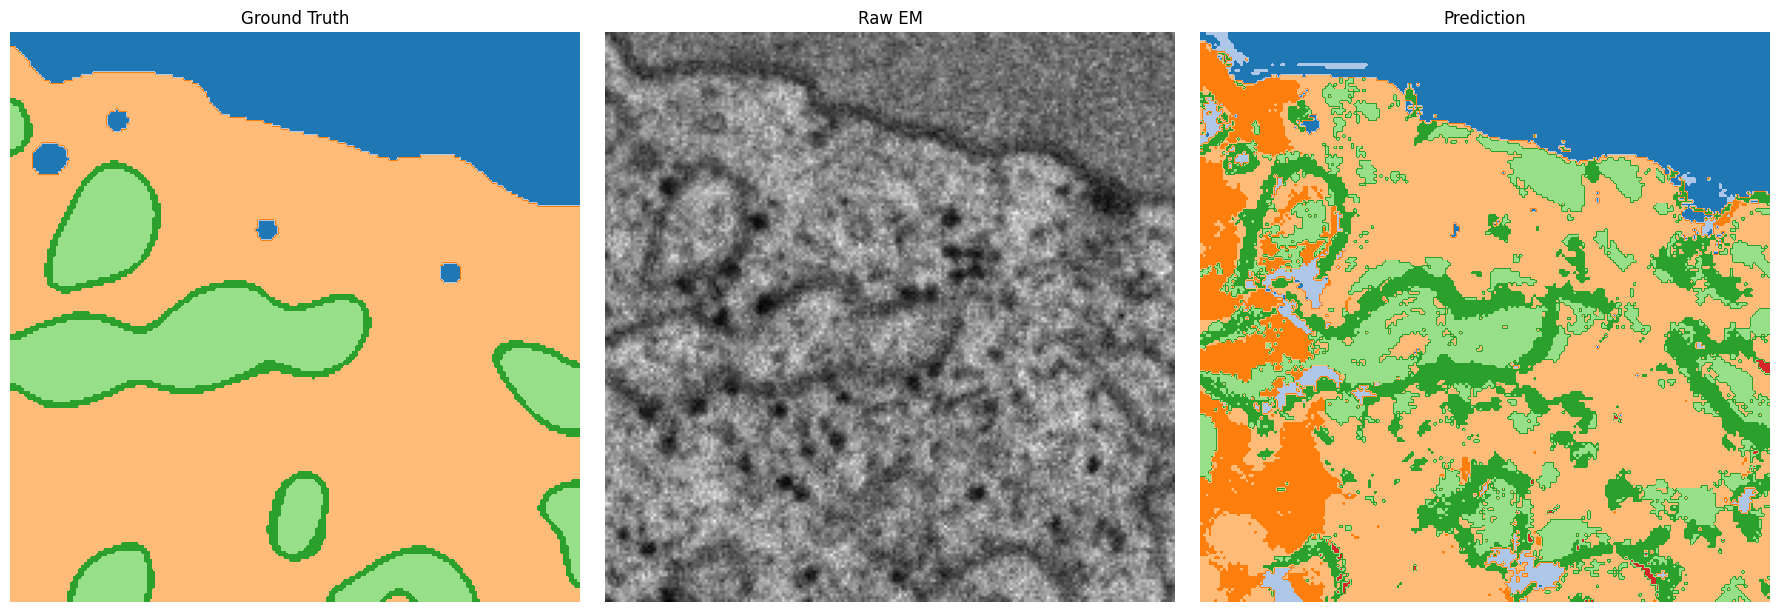

In [66]:
SLICE_Z = 50

show_gt_em_pred(
    em=em_test,
    gt=gt_int,
    pred=pred_int,
    z=SLICE_Z,
    cmap=cmap,
    norm=norm
)
